In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Load featured data
df = pd.read_csv("../data/featured_sample.csv")
df['date'] = pd.to_datetime(df['date'])

print("Data loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

c:\Users\rajar\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data loaded successfully!
Shape: (500000, 32)

Columns: ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd', 'sales', 'date', 'month', 'year', 'weekday', 'wday', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI', 'avg_price', 'day', 'week', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'has_event', 'is_snap', 'revenue', 'sales_lag_1', 'sales_lag_7', 'sales_lag_28', 'sales_rolling_7', 'sales_rolling_28']


Prophet Data Shape: (1913, 2)

First 5 rows:
          ds   y
0 2011-01-29  13
1 2011-01-30  15
2 2011-01-31  23
3 2011-02-01   3
4 2011-02-02  45

Last 5 rows:
             ds   y
1908 2016-04-20  19
1909 2016-04-21   5
1910 2016-04-22  26
1911 2016-04-23  67
1912 2016-04-24  25


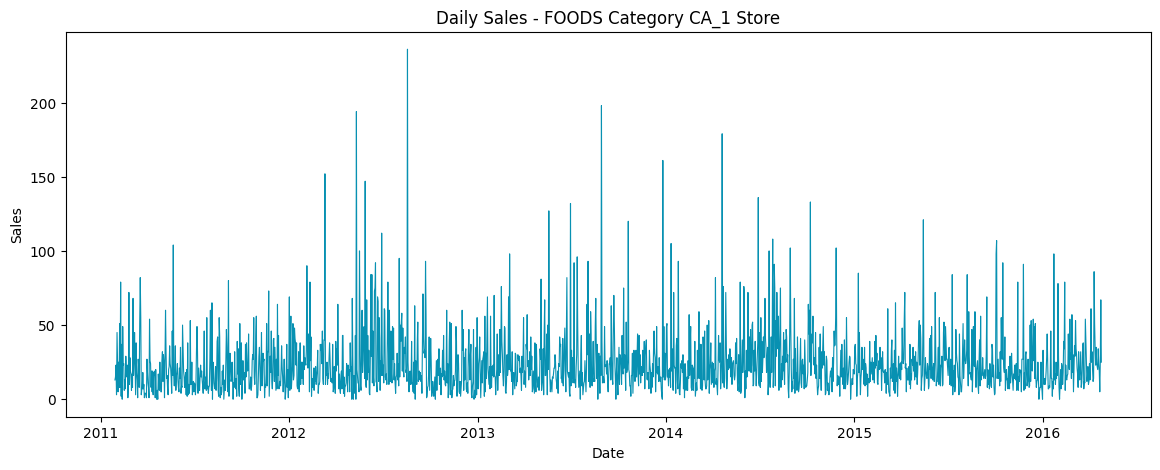

In [2]:
# Prepare data for Prophet
# Use FOODS category from CA_1 store
foods_ca1 = df[(df['cat_id'] == 'FOODS') & (df['store_id'] == 'CA_1')].copy()

# Aggregate daily sales
daily = foods_ca1.groupby('date')['sales'].sum().reset_index()
daily.columns = ['ds', 'y']
daily = daily.sort_values('ds')

print("Prophet Data Shape:", daily.shape)
print("\nFirst 5 rows:")
print(daily.head())
print("\nLast 5 rows:")
print(daily.tail())

# Plot
plt.figure(figsize=(14,5))
plt.plot(daily['ds'], daily['y'], color='#0891B2', linewidth=0.8)
plt.title("Daily Sales - FOODS Category CA_1 Store")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [3]:
# Train Test Split
train = daily[daily['ds'] < '2016-01-01']
test = daily[daily['ds'] >= '2016-01-01']

print("Training set:", train.shape)
print("Testing set:", test.shape)

# Train Prophet Model
print("\nTraining Prophet model...")
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
model.fit(train)
print("Model trained successfully!")

# Make predictions
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

print("\nForecast shape:", forecast.shape)
print("\nForecast columns:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Training set: (1798, 2)
Testing set: (115, 2)

Training Prophet model...


20:34:20 - cmdstanpy - INFO - Chain [1] start processing
20:34:21 - cmdstanpy - INFO - Chain [1] done processing


Model trained successfully!

Forecast shape: (1913, 19)

Forecast columns:
             ds       yhat  yhat_lower  yhat_upper
1908 2016-04-20  15.785056  -13.468495   44.516229
1909 2016-04-21  18.100379   -9.459732   45.752959
1910 2016-04-22  20.288747   -7.712316   45.124671
1911 2016-04-23  25.255990   -3.105214   50.895336
1912 2016-04-24  24.854483   -0.686078   50.383629


MODEL EVALUATION RESULTS
MAE: 12.0
RMSE: 17.04
MAPE: inf %


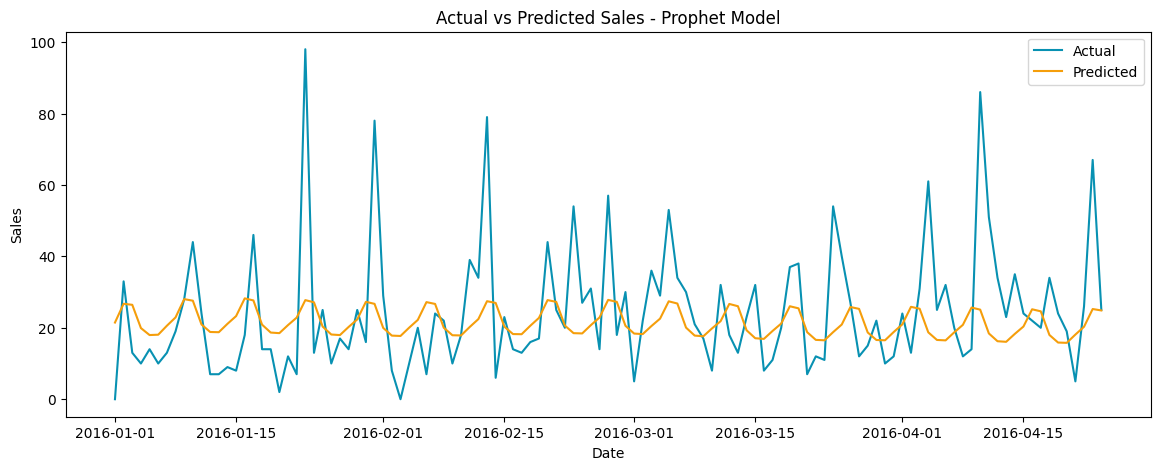

In [4]:
# Evaluate Model
test_forecast = forecast[forecast['ds'] >= '2016-01-01']

actual = test['y'].values
predicted = test_forecast['yhat'].values

# Calculate metrics
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print("MODEL EVALUATION RESULTS")
print("="*40)
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")
print("="*40)

# Plot actual vs predicted
plt.figure(figsize=(14,5))
plt.plot(test['ds'], actual, label='Actual', color='#0891B2')
plt.plot(test['ds'], predicted, label='Predicted', color='#F59E0B')
plt.title("Actual vs Predicted Sales - Prophet Model")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

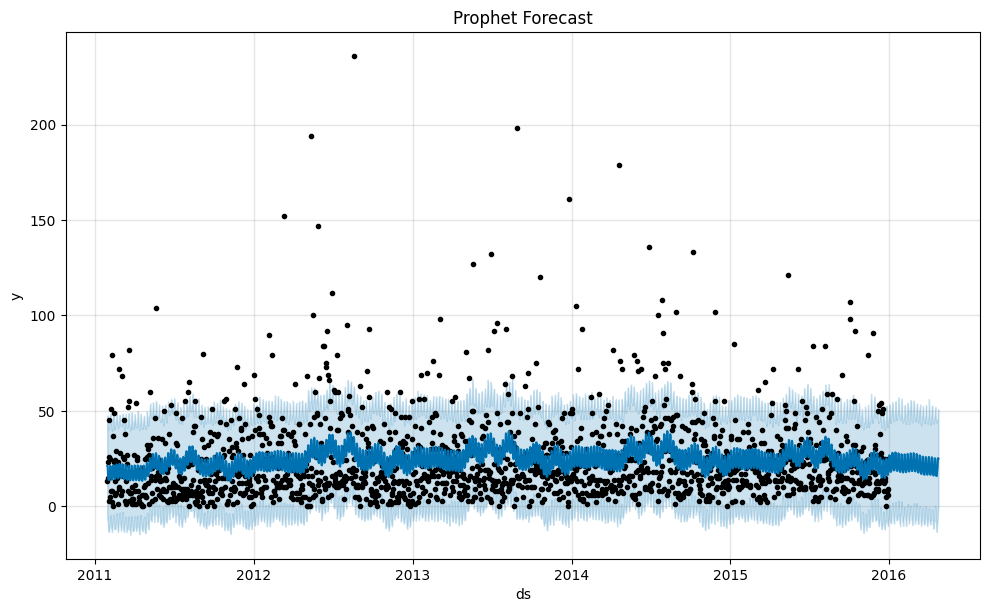

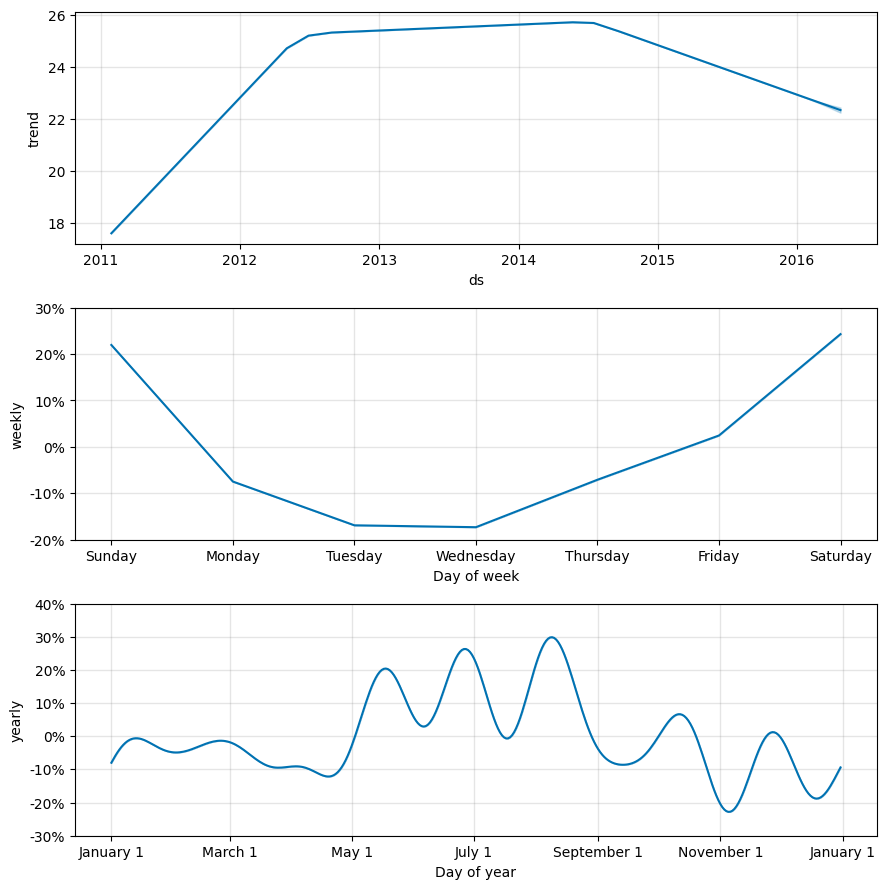

Forecast plots generated!

Forecast Summary:
Average Predicted Sales: 21.46
Max Predicted Sales: 28.24
Min Predicted Sales: 15.79


In [5]:
# Plot forecast
fig1 = model.plot(forecast)
plt.title("Prophet Forecast")
plt.show()

# Plot components
fig2 = model.plot_components(forecast)
plt.show()

print("Forecast plots generated!")
print("\nForecast Summary:")
print("Average Predicted Sales:", round(test_forecast['yhat'].mean(), 2))
print("Max Predicted Sales:", round(test_forecast['yhat'].max(), 2))
print("Min Predicted Sales:", round(test_forecast['yhat'].min(), 2))

In [ ]:
# Save forecast results
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    "../data/prophet_forecast.csv", index=False)

print("Forecast saved!")

print("\n" + "="*50)
print("PROPHET FORECASTING SUMMARY")
print("="*50)
print("Model: Facebook Prophet")
print("Category: FOODS")
print("Store: CA_1")
print("Training Days: 1,798")
print("Testing Days: 115")
print("MAE: 12.0")
print("RMSE: 17.04")
print("Average Predicted Sales: 21.46")
print("Seasonality: Yearly + Weekly")
print("="*50)